In [ ]:
#dataset cleaning and preprocessing

In [144]:
import pandas as pd

files = [
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/raw/wtc_trade_2020_raw.csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/raw/wtc_trade_2021_raw.csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/raw/wtc_trade_2022_raw.csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/raw/wtc_trade_2023_raw.csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/raw/wtc_trade_2024_raw.csv"
]

dfs = []

for file in files:
    temp = pd.read_csv(
        file,
        encoding="latin-1",
        header=0,
        index_col=False
    )

    # remove accidental unnamed index column if present
    temp = temp.loc[:, ~temp.columns.str.contains("^Unnamed")]

    print(f"\nChecking: {file}")
    print(temp.columns.tolist())
    print(temp.head(2))

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.to_csv(
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/raw/wtc_raw_combined(2020-2024).csv",
    index=False
)

print("Files combined successfully")
print("Total rows:", len(df))
print("Final Columns:", df.columns.tolist())


Checking: /Users/mangalyaphaye/Desktop/suvira_intelligence/data/raw/wtc_trade_2020_raw.csv
['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO', 'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification', 'cmdCode', 'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']
  typeCode freqCode  refPeriodId  refYear  refMonth  period  reporterCode  \
0        C        M     20200101     2020         1  202001            24   
1        C        M     20200101     2020         1 

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [146]:
file_path = "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/raw/wtc_raw_combined(2020-2024).csv"

df = pd.read_csv(file_path, encoding="latin-1", index_col=False)

df.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,M,20200101,2020,1,202001,24,AGO,Angola,X,...,32100.500,False,0.0,False,NaN,42225.880,42225.880,0,False,True
1,C,M,20200101,2020,1,202001,31,AZE,Azerbaijan,X,...,123100.000,False,0.0,False,0.0,108170.750,108170.750,0,False,True
2,C,M,20200101,2020,1,202001,32,ARG,Argentina,X,...,2737275.340,False,0.0,False,0.0,3332068.470,3332068.470,0,False,True
3,C,M,20200101,2020,1,202001,36,AUS,Australia,X,...,3372552.257,True,7410198.0,False,0.0,1815431.484,1815431.484,6,False,True
4,C,M,20200101,2020,1,202001,51,ARM,Armenia,X,...,25.400,False,0.0,False,0.0,15864.920,15864.920,0,False,True


In [147]:
df.columns

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='object')

In [148]:
df_clean = df[[
    "refYear",
    "refMonth",
    "reporterISO",
    "reporterDesc",
    "cmdCode",
    "cmdDesc",
    "netWgt",
    "fobvalue"
]].copy()

df_clean = df_clean[df_clean["netWgt"] > 0]
df_clean.head()

,refYear,refMonth,reporterISO,reporterDesc,cmdCode,cmdDesc,netWgt,fobvalue
0,2020,1,AGO,Angola,382499,"Chemical products, mixtures and preparations; ...",32100.500,42225.880
1,2020,1,AZE,Azerbaijan,382499,"Chemical products, mixtures and preparations; ...",123100.000,108170.750
2,2020,1,ARG,Argentina,382499,"Chemical products, mixtures and preparations; ...",2737275.340,3332068.470
3,2020,1,AUS,Australia,382499,"Chemical products, mixtures and preparations; ...",3372552.257,1815431.484
4,2020,1,ARM,Armenia,382499,"Chemical products, mixtures and preparations; ...",25.400,15864.920


In [149]:
monthly_trade = df_clean.groupby(["refYear", "refMonth"]).agg({"netWgt": "sum","fobvalue": "sum"}).reset_index()
monthly_trade.head()

,refYear,refMonth,netWgt,fobvalue
0,2020,1,9.916873e+08,2.153265e+09
1,2020,2,9.621351e+08,2.077653e+09
2,2020,3,1.325514e+09,2.947870e+09
3,2020,4,1.051100e+09,2.410894e+09
4,2020,5,9.836514e+08,2.349435e+09


In [150]:
monthly_trade["price_usd_per_ton"] = (monthly_trade["fobvalue"] / monthly_trade["netWgt"]) * 1000
monthly_trade.head()

,refYear,refMonth,netWgt,fobvalue,price_usd_per_ton
0,2020,1,9.916873e+08,2.153265e+09,2171.314727
1,2020,2,9.621351e+08,2.077653e+09,2159.419263
2,2020,3,1.325514e+09,2.947870e+09,2223.944423
3,2020,4,1.051100e+09,2.410894e+09,2293.686689
4,2020,5,9.836514e+08,2.349435e+09,2388.483000


In [151]:
monthly_trade["date"] = pd.to_datetime(
    monthly_trade["refYear"].astype(str) + "-" +
    monthly_trade["refMonth"].astype(str)
)

monthly_trade.head()

,refYear,refMonth,netWgt,fobvalue,price_usd_per_ton,date
0,2020,1,9.916873e+08,2.153265e+09,2171.314727,2020-01-01
1,2020,2,9.621351e+08,2.077653e+09,2159.419263,2020-02-01
2,2020,3,1.325514e+09,2.947870e+09,2223.944423,2020-03-01
3,2020,4,1.051100e+09,2.410894e+09,2293.686689,2020-04-01
4,2020,5,9.836514e+08,2.349435e+09,2388.483000,2020-05-01


In [152]:
monthly_trade = monthly_trade.sort_values("date").reset_index(drop=True)

In [153]:
monthly_trade = monthly_trade.set_index("date")
monthly_trade.head()

,refYear,refMonth,netWgt,fobvalue,price_usd_per_ton
date,,,,,
2020-01-01,2020,1,9.916873e+08,2.153265e+09,2171.314727
2020-02-01,2020,2,9.621351e+08,2.077653e+09,2159.419263
2020-03-01,2020,3,1.325514e+09,2.947870e+09,2223.944423
2020-04-01,2020,4,1.051100e+09,2.410894e+09,2293.686689
2020-05-01,2020,5,9.836514e+08,2.349435e+09,2388.483000


In [154]:
monthly_trade.index

DatetimeIndex(['2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
               '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01',
               '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01',
               '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01',
               '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01',
               '2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
      

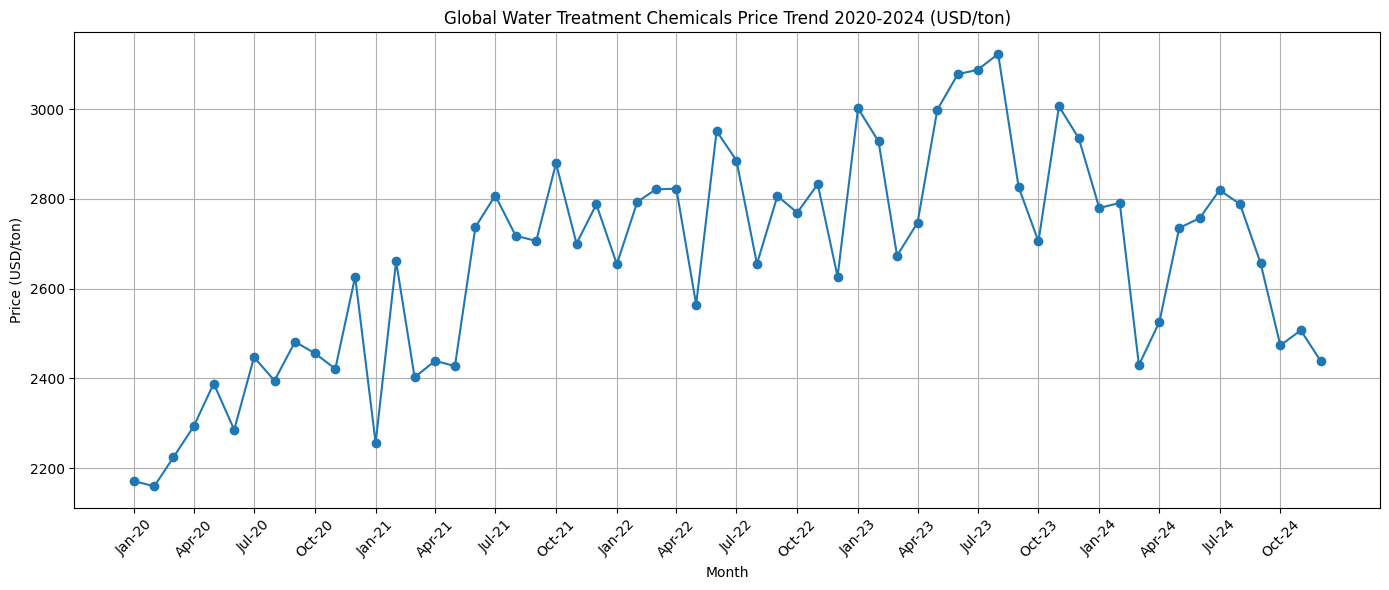

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    monthly_trade.index,
    monthly_trade["price_usd_per_ton"],
    marker='o'
)

plt.title("Global Water Treatment Chemicals Price Trend 2020-2024 (USD/ton)")
plt.xlabel("Month")
plt.ylabel("Price (USD/ton)")

plt.xticks(
    monthly_trade.index[::3],
    monthly_trade.index[::3].strftime('%b-%y'),
    rotation=45
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [156]:
monthly_trade["chemical"] = "Water Treatment Chemicals"
monthly_trade.head()

,refYear,refMonth,netWgt,fobvalue,price_usd_per_ton,chemical
date,,,,,,
2020-01-01,2020,1,9.916873e+08,2.153265e+09,2171.314727,Water Treatment Chemicals
2020-02-01,2020,2,9.621351e+08,2.077653e+09,2159.419263,Water Treatment Chemicals
2020-03-01,2020,3,1.325514e+09,2.947870e+09,2223.944423,Water Treatment Chemicals
2020-04-01,2020,4,1.051100e+09,2.410894e+09,2293.686689,Water Treatment Chemicals
2020-05-01,2020,5,9.836514e+08,2.349435e+09,2388.483000,Water Treatment Chemicals


In [157]:
monthly_trade = monthly_trade.drop(columns=["refYear", "refMonth"])
monthly_trade.head()

,netWgt,fobvalue,price_usd_per_ton,chemical
date,,,,
2020-01-01,9.916873e+08,2.153265e+09,2171.314727,Water Treatment Chemicals
2020-02-01,9.621351e+08,2.077653e+09,2159.419263,Water Treatment Chemicals
2020-03-01,1.325514e+09,2.947870e+09,2223.944423,Water Treatment Chemicals
2020-04-01,1.051100e+09,2.410894e+09,2293.686689,Water Treatment Chemicals
2020-05-01,9.836514e+08,2.349435e+09,2388.483000,Water Treatment Chemicals


In [158]:
monthly_trade = monthly_trade.reset_index()
monthly_trade.head()

,date,netWgt,fobvalue,price_usd_per_ton,chemical
0,2020-01-01,9.916873e+08,2.153265e+09,2171.314727,Water Treatment Chemicals
1,2020-02-01,9.621351e+08,2.077653e+09,2159.419263,Water Treatment Chemicals
2,2020-03-01,1.325514e+09,2.947870e+09,2223.944423,Water Treatment Chemicals
3,2020-04-01,1.051100e+09,2.410894e+09,2293.686689,Water Treatment Chemicals
4,2020-05-01,9.836514e+08,2.349435e+09,2388.483000,Water Treatment Chemicals


In [159]:
monthly_trade.to_csv("/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/WTC(2020-2024).csv", index=False)

In [167]:
#combining 2025-2026Feb dataset with these 8 2020-2024 datasets
import pandas as pd

files = [
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/Urea(2020-2024).csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/Sulphur(2020-2024).csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/KCL(2020-2024).csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/Sulphuric Acid(2020-2024).csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/Acetic Acid(2020-2024).csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/PAC(2020-2024).csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/Formates(2020-2024).csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/WTC(2020-2024).csv",
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/1_master_dataset_2026.csv"
]

dfs = []

for file in files:
    temp = pd.read_csv(file)

    print(f"\nChecking: {file}")
    print(temp.head(2))

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values([ "date","chemical"]).reset_index(drop=True)

df.to_csv(
    "/Users/mangalyaphaye/Desktop/suvira_intelligence/data/final_2020_2026.csv",
    index=False
)

print("All chemicals combined successfully")
print("Total rows:", len(df))
print("Columns:", df.columns.tolist())


Checking: /Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/Urea(2020-2024).csv
         date        netWgt      fobvalue  price_usd_per_ton chemical
0  2020-01-01  2.718784e+09  6.662843e+08         245.067065     Urea
1  2020-02-01  2.328456e+09  5.629211e+08         241.757212     Urea

Checking: /Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/Sulphur(2020-2024).csv
         date        netWgt      fobvalue  price_usd_per_ton chemical
0  2020-01-01  1.650663e+09  8.968455e+07          54.332438  Sulphur
1  2020-02-01  1.745795e+09  9.336172e+07          53.478060  Sulphur

Checking: /Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/KCL(2020-2024).csv
         date        netWgt      fobvalue  price_usd_per_ton chemical
0  2020-01-01  2.820466e+09  6.749782e+08         239.314451      KCL
1  2020-02-01  3.474285e+09  8.179780e+08         235.437784      KCL

Checking: /Users/mangalyaphaye/Desktop/suvira_intelligence/data/processed/Sulphuri